## 查看数据集

标注文件是 **COCO instance segmentation** 格式（额外带一个自定义的 `spine` 脊线字段），不是 LabelMe。

数据集特点：
1. 图片尺寸：2048 x 2048，单通道灰度 JPEG
2. 类别数量：4 个，分别为 Left / Right / Unidentifiable / Ambiguous（暗条磁场手性）
3. `images` 条目数 > 实际图片文件数：同一张图可能被多个标注者独立标注，`image_id` 形如 `标注者编号-文件名主干`
4. `annotations[i]['segmentation']` 是单个多边形 `[[x1,y1,x2,y2,...]]`，`bbox` 为 `[x, y, w, h]`，`iscrowd` 全为 0
5. `spine` 是自定义字段，展平的折线坐标 `[x1,y1,x2,y2,...]`，即暗条主轴脊线，是判定手性（Left/Right）的关键几何信息
6. 目标非常小，面积中位数约 1200 px²，占全图不到 0.03%，整图上的框几乎看不见，需要裁剪放大

### 0. 依赖

需要 `numpy` / `matplotlib` / `pillow`。如果当前内核没装，取消注释执行一次（装好后重启内核）。

In [18]:
# %pip install numpy matplotlib pillow

### 1. 加载标注文件并建立索引

In [19]:
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np

# ---------- 路径配置 ----------
DATA_ROOT = Path("datasets")
TRAIN_IMG_DIR = DATA_ROOT / "train" / "train_images"
TEST_IMG_DIR = DATA_ROOT / "test" / "test_images"
ANN_FILE = DATA_ROOT / "train" / "MAGFiLO_1.0_Annotations_kaggle2026_train.json"

with open(ANN_FILE, "r", encoding="utf-8") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = coco["categories"]

# ---------- 索引 ----------
cat_id2name = {c["id"]: c["name"] for c in categories}          # category_id -> 类别名
img_by_id = {im["id"]: im for im in images}                      # image_id -> image 条目

anns_by_img = defaultdict(list)                                  # image_id -> annotation 列表
anns_by_cat = defaultdict(list)                                  # category_id -> annotation 列表
for a in annotations:
    anns_by_img[a["image_id"]].append(a)
    anns_by_cat[a["category_id"]].append(a)

ids_by_file = defaultdict(list)                                  # 文件名 -> 多个标注者的 image_id
for im in images:
    ids_by_file[im["file_name"]].append(im["id"])

print("info:", coco["info"]["description"], "| version", coco["info"]["version"])
print("categories:", cat_id2name)

info: MLEcoFi 2024 Dataset - V1.0 | version 1.0
categories: {1: 'Left', 2: 'Right', 3: 'Unidentifiable', 4: 'Ambiguous'}


### 2. 整体数据量统计

In [20]:
unique_files = {im["file_name"] for im in images}
disk_train = {p.name for p in TRAIN_IMG_DIR.glob("*.jpeg")}
disk_test = {p.name for p in TEST_IMG_DIR.glob("*.jpeg")}
annotators = {im["id"].split("-")[0] for im in images}

print("=" * 56)
print("整体规模")
print("=" * 56)
print(f"images 条目数（图片 x 标注者）  : {len(images)}")
print(f"唯一图片文件数（json 中）       : {len(unique_files)}")
print(f"训练图片文件数（磁盘上）        : {len(disk_train)}")
print(f"测试图片文件数（磁盘上）        : {len(disk_test)}")
print(f"json 有标注但磁盘缺失的图片     : {len(unique_files - disk_train)}")
print(f"磁盘有但 json 无标注的图片      : {len(disk_train - unique_files)}")
print(f"标注者数量                      : {len(annotators)}")
print(f"annotation（实例）总数          : {len(annotations)}")
print()

print("每张图的标注者数量分布：")
per_file_annotators = Counter(len(v) for v in ids_by_file.values())
for k in sorted(per_file_annotators):
    print(f"  被 {k} 个标注者标注: {per_file_annotators[k]:>4} 张")
print()

inst_per_entry = [len(anns_by_img.get(im["id"], [])) for im in images]
print(f"单个 (图片, 标注者) 上的实例数: min={min(inst_per_entry)}, "
      f"median={int(np.median(inst_per_entry))}, mean={np.mean(inst_per_entry):.2f}, "
      f"max={max(inst_per_entry)}")
print("图片尺寸分布:", dict(Counter((im["width"], im["height"]) for im in images)))

整体规模
images 条目数（图片 x 标注者）  : 1154
唯一图片文件数（json 中）       : 707
训练图片文件数（磁盘上）        : 707
测试图片文件数（磁盘上）        : 180
json 有标注但磁盘缺失的图片     : 0
磁盘有但 json 无标注的图片      : 0
标注者数量                      : 37
annotation（实例）总数          : 8199

每张图的标注者数量分布：
  被 1 个标注者标注:  411 张
  被 2 个标注者标注:  145 张
  被 3 个标注者标注:  151 张

单个 (图片, 标注者) 上的实例数: min=1, median=7, mean=7.10, max=26
图片尺寸分布: {(2048, 2048): 1154}


### 3. 每个分类的数量统计

In [21]:
total_ann = len(annotations)
rows = []
for cid in sorted(cat_id2name):
    anns = anns_by_cat.get(cid, [])
    areas = [a["area"] for a in anns]
    ws = [a["bbox"][2] for a in anns]
    hs = [a["bbox"][3] for a in anns]
    n_spine_pts = [len(a.get("spine", [])) // 2 for a in anns]
    rows.append({
        "id": cid,
        "name": cat_id2name[cid],
        "n_inst": len(anns),
        "pct": len(anns) / total_ann * 100 if total_ann else 0.0,
        "n_files": len({img_by_id[a["image_id"]]["file_name"] for a in anns}),
        "area_med": float(np.median(areas)) if areas else 0.0,
        "area_min": min(areas) if areas else 0.0,
        "area_max": max(areas) if areas else 0.0,
        "w_med": float(np.median(ws)) if ws else 0.0,
        "h_med": float(np.median(hs)) if hs else 0.0,
        "spine_med": float(np.median(n_spine_pts)) if n_spine_pts else 0.0,
    })

hdr = (f"{'id':>3} {'name':<16} {'实例数':>8} {'占比%':>7} {'涉及图片':>8} "
       f"{'area中位':>9} {'area最小':>9} {'area最大':>9} {'w中位':>7} {'h中位':>7} {'spine点中位':>11}")
print(hdr)
print("-" * len(hdr))
for r in rows:
    print(f"{r['id']:>3} {r['name']:<16} {r['n_inst']:>8} {r['pct']:>7.2f} {r['n_files']:>8} "
          f"{r['area_med']:>9.1f} {r['area_min']:>9.1f} {r['area_max']:>9.1f} "
          f"{r['w_med']:>7.1f} {r['h_med']:>7.1f} {r['spine_med']:>11.1f}")
print("-" * len(hdr))
print(f"{'':>3} {'TOTAL':<16} {total_ann:>8} {100.0:>7.2f} {len(unique_files):>8}")

 id name                  实例数     占比%     涉及图片    area中位    area最小    area最大     w中位     h中位    spine点中位
--------------------------------------------------------------------------------------------------------
  1 Left                 2535   30.92      605    1438.0      60.0   37739.0    87.3    85.4        12.0
  2 Right                2590   31.59      598    1524.0       9.0   21158.0    92.3    84.4        13.0
  3 Unidentifiable       3074   37.49      631     868.5      73.0   35251.0    55.2    50.5         7.0
  4 Ambiguous               0    0.00        0       0.0       0.0       0.0     0.0     0.0         0.0
--------------------------------------------------------------------------------------------------------
    TOTAL                8199  100.00      707


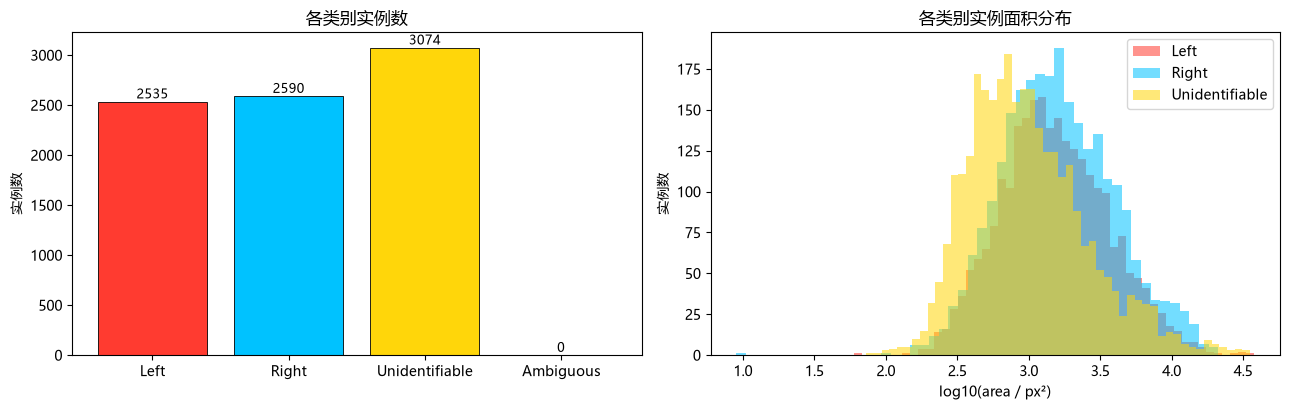

In [22]:
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 每个类别一个固定颜色，画框时复用
CAT_COLORS = {1: "#ff3b30", 2: "#00c2ff", 3: "#ffd60a", 4: "#ff2df7"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

names = [r["name"] for r in rows]
counts = [r["n_inst"] for r in rows]
bars = axes[0].bar(names, counts, color=[CAT_COLORS[r["id"]] for r in rows],
                   edgecolor="black", linewidth=0.6)
axes[0].set_title("各类别实例数")
axes[0].set_ylabel("实例数")
for b, c in zip(bars, counts):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height(), str(c),
                 ha="center", va="bottom", fontsize=9)

for cid in sorted(cat_id2name):
    areas = [a["area"] for a in anns_by_cat.get(cid, [])]
    if areas:
        axes[1].hist(np.log10(areas), bins=50, alpha=0.55,
                     label=cat_id2name[cid], color=CAT_COLORS[cid])
axes[1].set_title("各类别实例面积分布")
axes[1].set_xlabel("log10(area / px²)")
axes[1].set_ylabel("实例数")
axes[1].legend()

plt.tight_layout()
plt.show()

### 4. 看每个类别的标注样子（重点看 spine 脊线）

暗条在 2048x2048 全图里只占万分之几，整图上的框看不清，所以按 bbox 裁剪局部放大。
每张示意图上叠加三层信息：

| 元素 | 画法 |
| --- | --- |
| `bbox` | 类别色点线框 |
| `segmentation` 多边形 | 类别色半透明填充 |
| **`spine` 脊线** | 无方向的亮绿粗线 + 顶点圆点 |

同时在图下方打印每个实例的 spine 数值：点数、弧长、端点距离、弯曲比以及完整坐标。spine 坐标顺序只用于连接折线，不代表物理方向。

In [23]:
from matplotlib.patches import Polygon, Rectangle
from matplotlib.lines import Line2D
from PIL import Image

SPINE_COLOR = "#39ff14"      # 无方向脊线主色（亮绿，在灰度日面上最醒目）


def load_image(file_name):
    """按文件名读训练图，返回灰度 ndarray。"""
    return np.array(Image.open(TRAIN_IMG_DIR / file_name).convert("L"))


def spine_xy(ann):
    """spine 展平坐标 [x1,y1,x2,y2,...] -> (N,2) 数组。"""
    return np.asarray(ann.get("spine") or [], dtype=float).reshape(-1, 2)


def spine_length(pts):
    """脊线折线弧长（像素）。"""
    if len(pts) < 2:
        return 0.0
    return float(np.linalg.norm(np.diff(pts, axis=0), axis=1).sum())


def draw_ann(ax, ann, offset=(0.0, 0.0), lw=1.4, show_spine=True):
    """把一个 annotation 画到 ax 上。offset 为裁剪图的坐标平移 (dx, dy)。"""
    dx, dy = offset
    color = CAT_COLORS.get(ann["category_id"], "#ffffff")

    # ---- 分割多边形 ----
    for seg in ann["segmentation"]:
        pts = np.asarray(seg, dtype=float).reshape(-1, 2) - (dx, dy)
        ax.add_patch(Polygon(pts, closed=True, facecolor=color, alpha=0.22,
                             edgecolor=color, linewidth=lw, zorder=2))

    # ---- bbox ----
    x, y, w, h = ann["bbox"]
    ax.add_patch(Rectangle((x - dx, y - dy), w, h, fill=False, edgecolor=color,
                           linewidth=lw, linestyle=":", zorder=3))

    # ---- spine 脊线：手性判定的关键，画成主视觉元素 ----
    sp = spine_xy(ann)
    if show_spine and len(sp):
        sp = sp - (dx, dy)
        # 黑色描边打底，保证在亮/暗背景上都看得清
        ax.plot(sp[:, 0], sp[:, 1], color="black", linewidth=lw + 2.6,
                solid_capstyle="round", zorder=4)
        ax.plot(sp[:, 0], sp[:, 1], color=SPINE_COLOR, linewidth=lw + 0.8,
                solid_capstyle="round", zorder=5)
        # 脊线顶点
        ax.plot(sp[:, 0], sp[:, 1], "o", color=SPINE_COLOR, markersize=2.8,
                markeredgecolor="black", markeredgewidth=0.4, zorder=6)


def crop_around(ann, img, pad_ratio=0.6, min_pad=40):
    """围绕 bbox 裁一块方形区域，返回 (patch, x0, y0)。"""
    H, W = img.shape[:2]
    x, y, w, h = ann["bbox"]
    cx, cy = x + w / 2, y + h / 2
    side = max(max(w, h) * (1 + 2 * pad_ratio), 2 * min_pad)
    x0 = int(np.clip(cx - side / 2, 0, W - 1))
    y0 = int(np.clip(cy - side / 2, 0, H - 1))
    x1 = int(np.clip(cx + side / 2, 1, W))
    y1 = int(np.clip(cy + side / 2, 1, H))
    return img[y0:y1, x0:x1], x0, y0


def print_spine_info(ann, tag="", max_pts=40, decimals=1):
    """打印单个实例的 spine 数值信息。"""
    sp = spine_xy(ann)
    file_name = img_by_id[ann["image_id"]]["file_name"]
    print(f"{tag} {file_name} | 标注者 {ann['image_id'].split('-')[0]} | "
          f"{cat_id2name[ann['category_id']]} | ann_id={str(ann['id'])[:8]}")
    if not len(sp):
        print("     spine: 空")
        return
    end_distance = np.linalg.norm(sp[-1] - sp[0])
    print(f"     点数={len(sp)}  弧长={spine_length(sp):.1f}px  "
          f"端点距离={end_distance:.1f}px  "
          f"弯曲比={spine_length(sp) / max(end_distance, 1e-6):.2f}")
    pts = np.round(sp, decimals).tolist()
    if len(pts) <= max_pts:
        print(f"     坐标({len(pts)}点)={pts}")
    else:
        head, tail = pts[: max_pts // 2], pts[-max_pts // 2:]
        print(f"     坐标({len(pts)}点，首尾各{max_pts // 2}个)={head} ... {tail}")


def show_category_samples(cat_id, n=4, seed=42, pad_ratio=0.6, ax_size=3.4,
                          print_spine=True, max_pts=40):
    """随机抽 n 个该类别的实例，裁剪放大画出 bbox / mask / spine，并打印 spine 数值。"""
    pool = anns_by_cat.get(cat_id, [])
    if not pool:
        print(f"类别 {cat_id} ({cat_id2name.get(cat_id)}) 没有任何标注实例，跳过\n")
        return

    picks = random.Random(seed).sample(pool, min(n, len(pool)))
    fig, axes = plt.subplots(1, len(picks), figsize=(ax_size * len(picks), ax_size + 1.1),
                             squeeze=False)
    for k, (ax, a) in enumerate(zip(axes[0], picks), 1):
        file_name = img_by_id[a["image_id"]]["file_name"]
        patch, x0, y0 = crop_around(a, load_image(file_name), pad_ratio=pad_ratio)
        ax.imshow(patch, cmap="gray")
        draw_ann(ax, a, offset=(x0, y0))
        sp = spine_xy(a)
        ax.set_title(f"[{k}] {file_name[:14]}\n"
                     f"area={a['area']:.0f}  bbox={a['bbox'][2]:.0f}x{a['bbox'][3]:.0f}\n"
                     f"spine: {len(sp)}点  {spine_length(sp):.0f}px", fontsize=8)
        ax.axis("off")

    handles = [
        Line2D([0], [0], color=SPINE_COLOR, lw=2.4, marker="o", markersize=3,
               markeredgecolor="black", label="spine（无方向）"),
        Line2D([0], [0], color=CAT_COLORS.get(cat_id, "black"), lw=1.6,
               linestyle=":", label="bbox"),
        Rectangle((0, 0), 1, 1, facecolor=CAT_COLORS.get(cat_id, "black"), alpha=0.35,
                  label="segmentation"),
    ]
    fig.suptitle(f"类别 {cat_id} - {cat_id2name[cat_id]}（共 {len(pool)} 个实例）",
                 fontsize=13, color=CAT_COLORS.get(cat_id, "black"))
    fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, fontsize=8)
    plt.tight_layout(rect=(0, 0.06, 1, 0.9))
    plt.show()

    if print_spine:
        print(f"===== 类别 {cat_id} {cat_id2name[cat_id]} 的 spine 数值 =====")
        for k, a in enumerate(picks, 1):
            print_spine_info(a, tag=f"[{k}]", max_pts=max_pts)
        print()

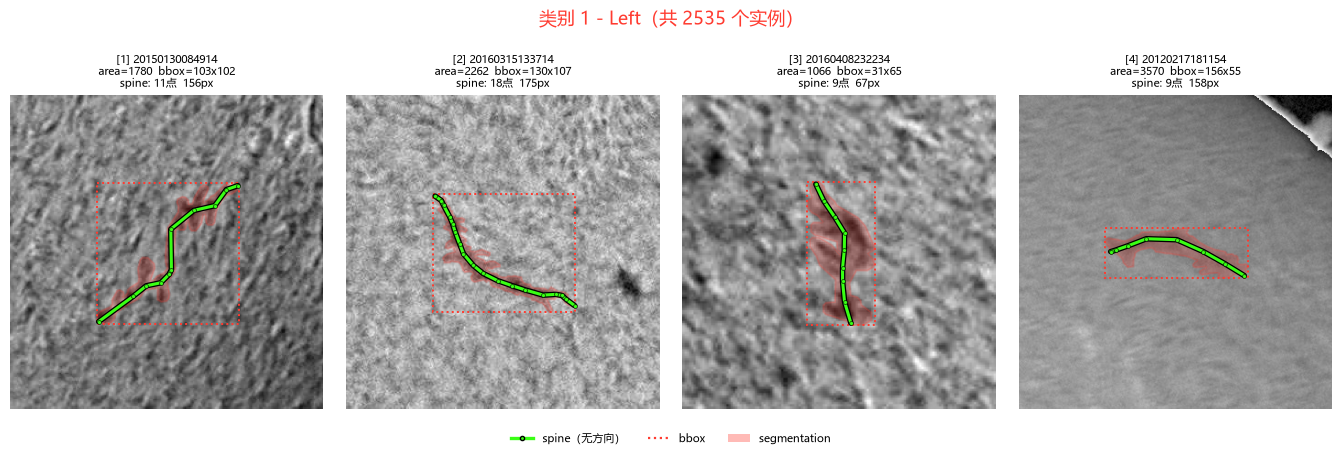

===== 类别 1 Left 的 spine 数值 =====
[1] 20150130084914Th.jpeg | 标注者 030101 | Left | ann_id=e96067aa
     点数=11  弧长=156.5px  端点距离=141.6px  弯曲比=1.11
     坐标(11点)=[[1547.0, 1415.3], [1572.2, 1396.8], [1581.7, 1389.2], [1592.3, 1387.0], [1598.3, 1380.8], [1599.9, 1377.4], [1599.5, 1348.0], [1616.2, 1334.4], [1631.5, 1330.9], [1640.0, 1319.2], [1648.2, 1316.3]]
[2] 20160315133714Th.jpeg | 标注者 010302 | Left | ann_id=8643e1ef
     点数=18  弧长=174.9px  端点距离=161.2px  弯曲比=1.09
     坐标(18点)=[[821.4, 1036.4], [827.0, 1040.3], [829.0, 1044.6], [834.6, 1055.2], [837.2, 1061.4], [839.5, 1068.7], [843.8, 1080.2], [847.1, 1088.8], [856.0, 1099.3], [864.9, 1106.6], [878.0, 1113.1], [891.2, 1117.8], [903.4, 1121.7], [919.6, 1126.3], [931.1, 1125.7], [936.5, 1126.7], [940.6, 1130.3], [948.2, 1135.9]]
[3] 20160408232234Lh.jpeg | 标注者 030101 | Left | ann_id=b4715bf9
     点数=9  弧长=67.5px  端点距离=65.3px  弯曲比=1.03
     坐标(9点)=[[511.4, 1179.1], [514.9, 1186.6], [520.0, 1194.2], [524.4, 1201.4], [524.3, 1209.3], [523.5,

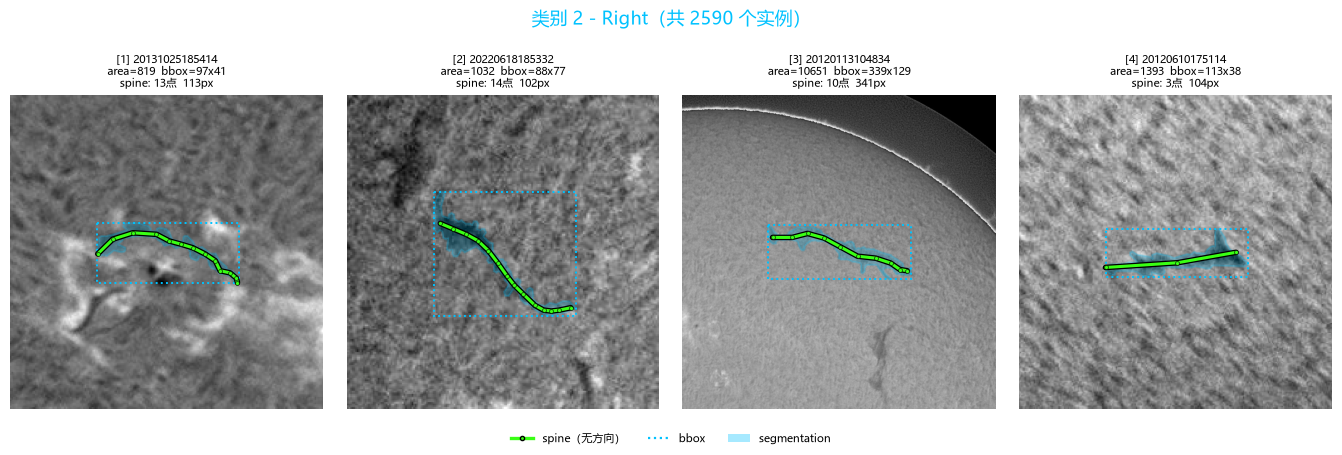

===== 类别 2 Right 的 spine 数值 =====
[1] 20131025185414Mh.jpeg | 标注者 010101 | Right | ann_id=a401b8d0
     点数=13  弧长=112.5px  端点距离=97.4px  弯曲比=1.16
     坐标(13点)=[[978.4, 1269.9], [988.7, 1259.9], [1002.4, 1255.5], [1018.5, 1256.5], [1027.1, 1261.0], [1035.1, 1263.2], [1043.4, 1265.7], [1051.8, 1270.0], [1058.7, 1274.6], [1061.9, 1281.4], [1068.7, 1282.8], [1073.0, 1286.4], [1073.8, 1289.5]]
[2] 20220618185332Bh.jpeg | 标注者 040401 | Right | ann_id=6f8c17aa
     点数=14  弧长=102.4px  端点距离=96.2px  弯曲比=1.06
     坐标(14点)=[[471.2, 711.9], [479.0, 715.1], [487.4, 718.7], [494.5, 722.6], [501.0, 728.7], [506.8, 736.3], [512.4, 744.3], [517.0, 750.2], [522.6, 755.7], [529.8, 762.7], [535.1, 765.5], [539.9, 766.2], [544.9, 765.5], [552.0, 764.1]]
[3] 20120113104834Ch.jpeg | 标注者 050302 | Right | ann_id=a7c900c1
     点数=10  弧长=340.9px  端点距离=329.7px  弯曲比=1.03
     坐标(10点)=[[1157.9, 431.2], [1204.6, 431.2], [1241.1, 421.7], [1280.4, 432.5], [1318.9, 453.5], [1360.2, 475.8], [1403.5, 480.6], [1438.7, 492.1]

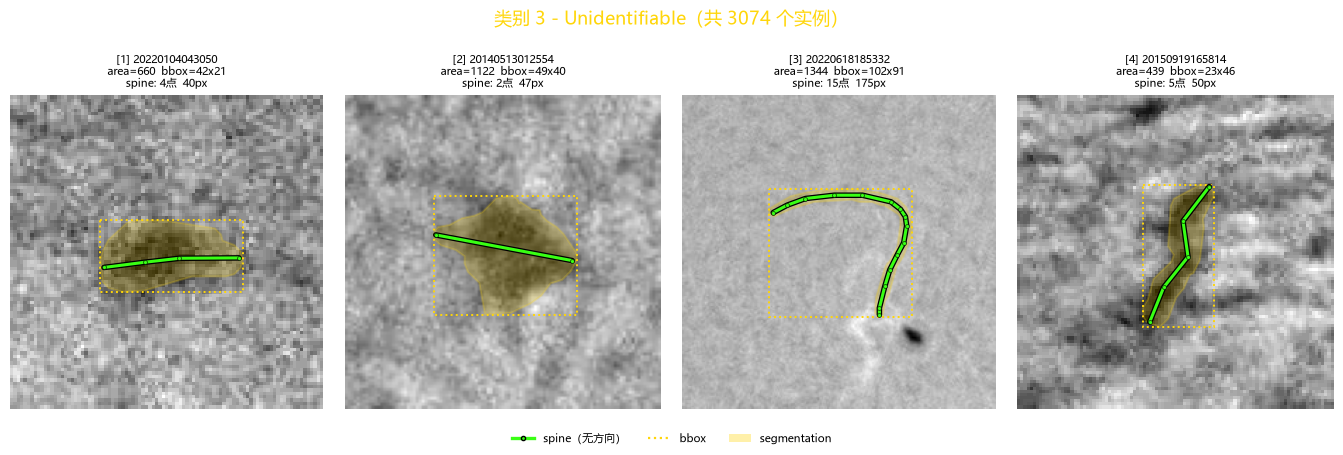

===== 类别 3 Unidentifiable 的 spine 数值 =====
[1] 20220104043050Uh.jpeg | 标注者 040302 | Unidentifiable | ann_id=90b8537e
     点数=4  弧长=40.2px  端点距离=40.2px  弯曲比=1.00
     坐标(4点)=[[1212.4, 629.6], [1224.6, 628.1], [1234.8, 626.9], [1252.5, 626.8]]
[2] 20140513012554Uh.jpeg | 标注者 010102 | Unidentifiable | ann_id=111da7fb
     点数=2  弧长=46.9px  端点距离=46.9px  弯曲比=1.00
     坐标(2点)=[[1026.3, 599.8], [1072.4, 608.5]]
[3] 20220618185332Bh.jpeg | 标注者 040401 | Unidentifiable | ann_id=a2553fcb
     点数=15  弧长=174.8px  端点距离=104.8px  弯曲比=1.67
     坐标(15点)=[[872.1, 940.1], [882.1, 934.8], [895.0, 930.1], [915.5, 927.7], [935.5, 927.7], [955.8, 932.4], [962.6, 937.7], [966.1, 943.0], [967.0, 949.5], [964.9, 961.5], [960.2, 970.3], [954.9, 980.9], [951.4, 992.6], [947.6, 1007.9], [947.6, 1012.6]]
[4] 20150919165814Mh.jpeg | 标注者 030101 | Unidentifiable | ann_id=d2384cec
     点数=5  弧长=49.7px  端点距离=47.2px  弯曲比=1.05
     坐标(5点)=[[820.8, 681.9], [825.2, 670.8], [833.0, 661.1], [831.4, 649.7], [839.8, 638.7]]

类别 4

In [24]:
# 每个类别看 4 个样例；换 seed 就换一批，改 n 控制数量
# print_spine=False 可以只看图不打印坐标；max_pts 控制坐标打印上限
for cid in sorted(cat_id2name):
    show_category_samples(cid, n=4, seed=42, print_spine=True, max_pts=40)

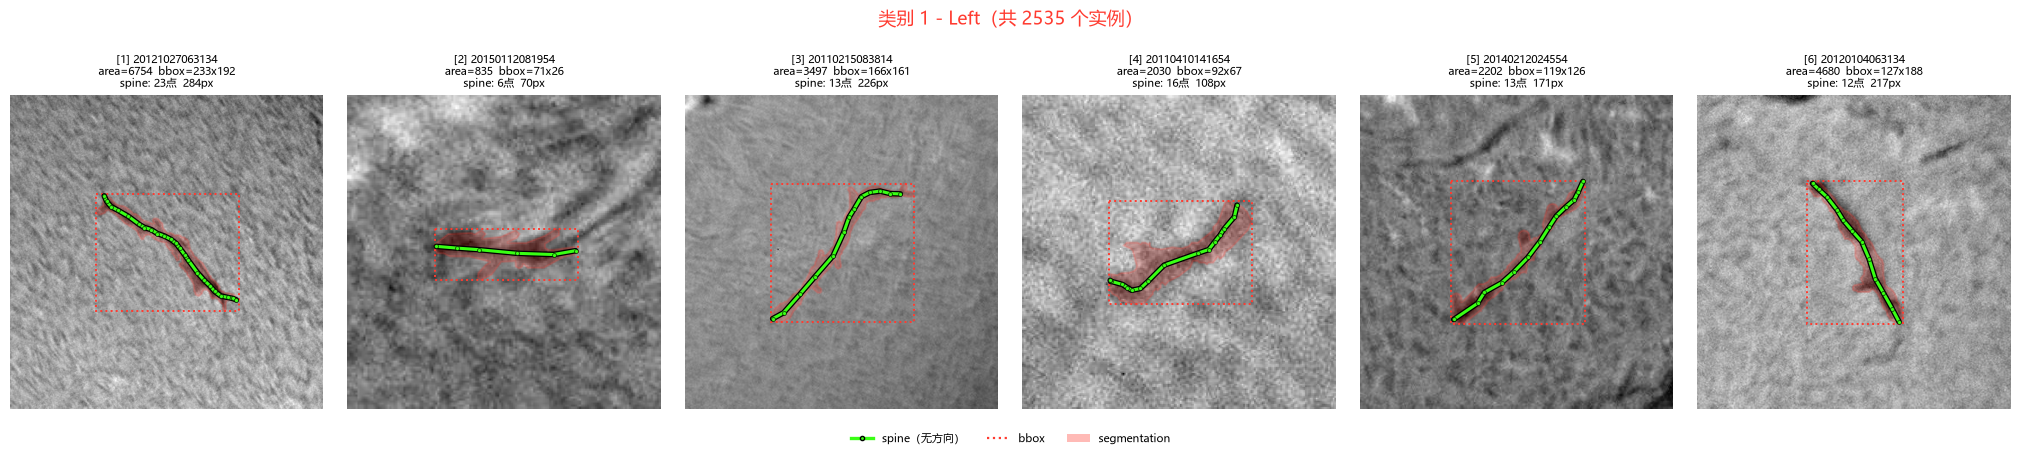

===== 类别 1 Left 的 spine 数值 =====
[1] 20121027063134Lh.jpeg | 标注者 010302 | Left | ann_id=f91656d0
     点数=23  弧长=283.9px  端点距离=275.1px  弯曲比=1.03
     坐标(23点)=[[1168.7, 575.4], [1172.7, 584.4], [1179.7, 592.8], [1190.6, 598.8], [1208.1, 608.7], [1225.5, 621.7], [1234.5, 627.2], [1245.9, 630.7], [1255.9, 637.1], [1267.3, 641.1], [1277.8, 646.6], [1286.2, 653.1], [1292.7, 661.5], [1301.2, 673.0], [1306.2, 680.4], [1321.1, 700.9], [1332.0, 713.3], [1342.0, 722.8], [1349.5, 731.7], [1359.4, 739.2], [1370.9, 741.7], [1378.8, 743.2], [1384.8, 745.7]]
[2] 20150112081954Uh.jpeg | 标注者 010103 | Left | ann_id=8b61a5de
     点数=6  弧长=70.1px  端点距离=69.8px  弯曲比=1.00
     坐标(6点)=[[1063.0, 805.2], [1073.3, 806.1], [1084.2, 806.9], [1103.4, 808.7], [1121.7, 809.3], [1132.7, 807.4]]
[3] 20110215083814Th.jpeg | 标注者 010403 | Left | ann_id=e7c76ef5
     点数=13  弧长=225.9px  端点距离=207.9px  弯曲比=1.09
     坐标(13点)=[[1417.6, 1458.9], [1430.3, 1451.9], [1449.3, 1430.5], [1466.6, 1410.3], [1488.0, 1385.6], [1500.3, 1358

In [25]:
# 只看某一个类别，多抽几个
show_category_samples(1, n=6, seed=7, print_spine=True)

### 5. spine 形态对比：Left vs Right

把脊线单独抽出来、平移到自身中心后并排画，去掉背景干扰，观察 spine 本身是否存在类别差异。
注意：spine 是无方向曲线，单独看它通常不能判断 Left/Right；左右性主要来自两侧 barb 相对 spine 的形态。

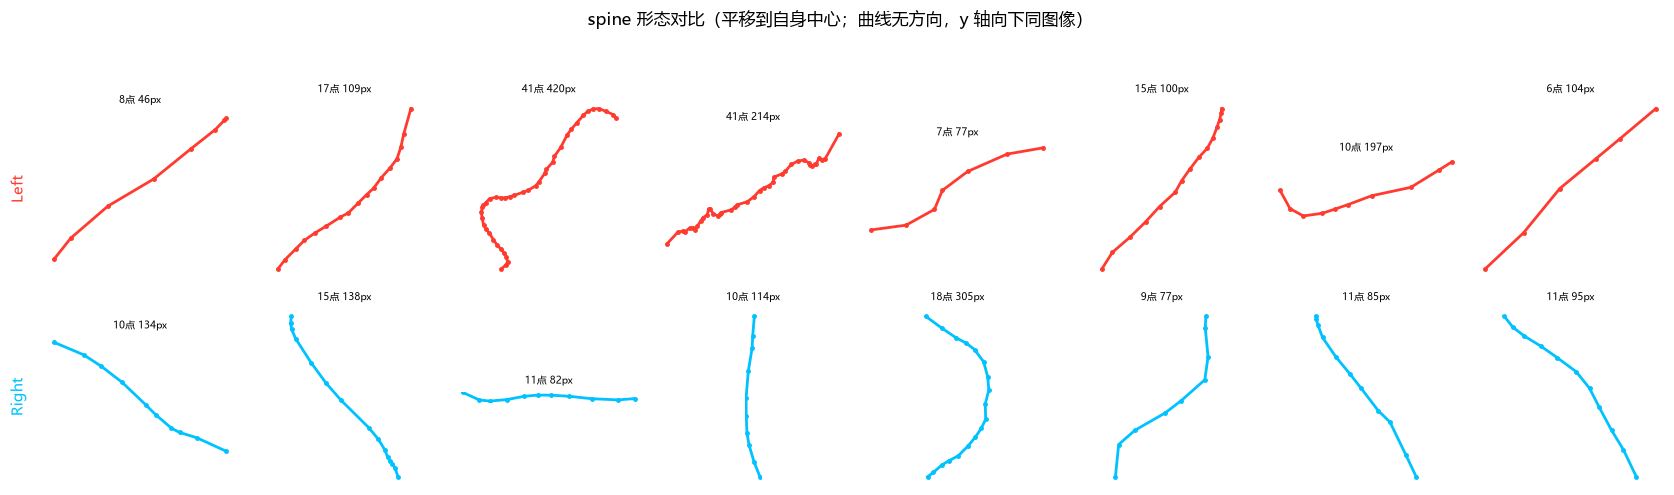

In [26]:
def compare_spine_shapes(cat_ids=(1, 2), n=8, seed=3, ax_size=2.1, min_pts=3):
    """每个类别一行，画 n 条平移到自身中心的无方向 spine 折线。"""
    rng = random.Random(seed)
    fig, axes = plt.subplots(len(cat_ids), n,
                             figsize=(ax_size * n, ax_size * len(cat_ids) + 0.8),
                             squeeze=False)
    for r, cid in enumerate(cat_ids):
        pool = [a for a in anns_by_cat.get(cid, []) if len(spine_xy(a)) >= min_pts]
        picks = rng.sample(pool, min(n, len(pool)))
        for c in range(n):
            ax = axes[r][c]
            ax.axis("off")
            if c >= len(picks):
                continue
            sp = spine_xy(picks[c])
            sp = sp - sp.mean(axis=0)             # 平移到自身中心，不赋予方向
            ax.plot(sp[:, 0], sp[:, 1], color=CAT_COLORS[cid], lw=2.0, zorder=2)
            ax.plot(sp[:, 0], sp[:, 1], "o", color=CAT_COLORS[cid], markersize=2.5, zorder=3)
            ax.set_aspect("equal")
            ax.invert_yaxis()                    # 与图像坐标一致
            ax.set_title(f"{len(sp)}点 {spine_length(sp):.0f}px", fontsize=7)
            if c == 0:
                ax.text(-0.1, 0.5, cat_id2name[cid], transform=ax.transAxes,
                        rotation=90, va="center", ha="right", fontsize=11,
                        color=CAT_COLORS[cid])
    fig.suptitle("spine 形态对比（平移到自身中心；曲线无方向，y 轴向下同图像）",
                 fontsize=12)
    plt.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()


compare_spine_shapes(cat_ids=(1, 2), n=8, seed=3)

### 6. 结论与下一步

- Left / Right / Unidentifiable 三类量级相近，类别不均衡不严重；`Ambiguous` 在训练集中无样本，建模时可只保留 3 类。
- `spine` 是非 COCO 标准字段，训练框架不会自动读，需要自己保留。它是暗条主轴，手性判定依赖脊线加两侧 barb（羽状体）的偏转方向，因此单看 spine 折线本身未必能线性区分 Left/Right，更可能需要把 spine 作为额外监督信号（比如脊线热图 / 方向场辅助分支）而不是直接分类特征。第 5 节的对比图可以先目视验证这一点。
- `annotations[i]['id']` 是 UUID 字符串，`image_id` 也是字符串，不符合 COCO 的 int 约定。接 `pycocotools` / mmdet / detectron2 前需要重映射成连续整数，并保留映射表用于生成提交。
- 一张图最多有 3 个独立标注者的版本，需要先定标签融合策略（并集 / 多数投票 / 随机选一个 / 软标签），这会直接影响训练集构造和本地验证的可信度。
- 目标极小（面积中位数约 1200 px²），全图直接送模型浪费算力，建议滑窗切图或先做日面 ROI 定位再分割。

## 7. Mask R-CNN 实例分割训练

### 模块 1：按唯一图像分组切分数据

同一个 `file_name` 的不同标注者版本始终进入同一集合，避免相同像素同时出现在训练集和验证集。优先按每张图的主类别分层；条件不满足或未安装 scikit-learn 时自动退化为固定随机种子分组切分。

In [ ]:
from collections import Counter, defaultdict
from pathlib import Path
import json
import random

SPLIT_SEED = 42
VAL_RATIO = 0.20
VALID_CATEGORY_IDS = (1, 2, 3)  # Left、Right、Unidentifiable；0 留给背景
ARTIFACT_DIR = Path('artifacts/maskrcnn')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# 一个 file_name 可能对应多个标注者 image_id；切分单位必须是 file_name。
file_to_image_ids = defaultdict(list)
for image_info in images:
    file_to_image_ids[image_info['file_name']].append(image_info['id'])

all_files = sorted(file_to_image_ids)
file_category_counts = {file_name: Counter() for file_name in all_files}
for ann in annotations:
    category_id = int(ann['category_id'])
    if category_id in VALID_CATEGORY_IDS:
        file_name = img_by_id[ann['image_id']]['file_name']
        file_category_counts[file_name][category_id] += 1

# 以实例数最多的类别作为分层标签；无有效实例的图像标记为 0。
stratify_labels = [
    file_category_counts[file_name].most_common(1)[0][0]
    if file_category_counts[file_name] else 0
    for file_name in all_files
]

try:
    from sklearn.model_selection import train_test_split

    label_counts = Counter(stratify_labels)
    can_stratify = (
        len(label_counts) > 1
        and min(label_counts.values()) >= 2
        and round(len(all_files) * VAL_RATIO) >= len(label_counts)
    )
    train_files, val_files = train_test_split(
        all_files,
        test_size=VAL_RATIO,
        random_state=SPLIT_SEED,
        shuffle=True,
        stratify=stratify_labels if can_stratify else None,
    )
    split_strategy = 'dominant_category_stratified' if can_stratify else 'group_random_fallback'
except (ImportError, ValueError):
    shuffled_files = all_files.copy()
    random.Random(SPLIT_SEED).shuffle(shuffled_files)
    val_count = max(1, round(len(shuffled_files) * VAL_RATIO))
    val_files = shuffled_files[:val_count]
    train_files = shuffled_files[val_count:]
    split_strategy = 'group_random_fallback'

train_file_set = set(train_files)
val_file_set = set(val_files)
assert train_file_set.isdisjoint(val_file_set), '训练集和验证集存在 file_name 泄漏'
assert train_file_set | val_file_set == set(all_files), '切分后存在图像遗漏'

# 保留所有标注者版本，但相同 file_name 只会属于一个 split。
train_records = [info for info in images if info['file_name'] in train_file_set]
val_records = [info for info in images if info['file_name'] in val_file_set]
assert {r['file_name'] for r in train_records}.isdisjoint({r['file_name'] for r in val_records})

split_manifest = {
    'seed': SPLIT_SEED,
    'val_ratio': VAL_RATIO,
    'strategy': split_strategy,
    'train_files': sorted(train_file_set),
    'val_files': sorted(val_file_set),
    'train_image_ids': [record['id'] for record in train_records],
    'val_image_ids': [record['id'] for record in val_records],
}
with (ARTIFACT_DIR / 'split_manifest.json').open('w', encoding='utf-8') as f:
    json.dump(split_manifest, f, ensure_ascii=False, indent=2)

print(f'切分策略: {split_strategy}')
print(f'唯一图像: train={len(train_file_set)}, val={len(val_file_set)}')
print(f'标注者记录: train={len(train_records)}, val={len(val_records)}')

### 模块 2：定义 Dataset 和 DataLoader

将 COCO polygon/RLE 栅格化为实例 mask，并由 mask 重新计算边界框。这里不使用普通翻转增强，因为翻转会改变 Left/Right 手性语义。

In [ ]:
import numpy as np
from PIL import Image, ImageDraw
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF

def segmentation_to_mask(segmentation, height, width):
    """把 COCO polygon 或 RLE 转成 uint8 二值 mask。"""
    if isinstance(segmentation, dict):
        try:
            from pycocotools import mask as mask_utils
        except ImportError as exc:
            raise ImportError('读取 RLE segmentation 需要安装 pycocotools') from exc
        decoded = mask_utils.decode(segmentation)
        if decoded.ndim == 3:
            decoded = decoded.any(axis=2)
        return decoded.astype(np.uint8)

    mask_image = Image.new('L', (width, height), 0)
    drawer = ImageDraw.Draw(mask_image)
    polygons = segmentation if isinstance(segmentation, list) else []
    if polygons and isinstance(polygons[0], (int, float)):
        polygons = [polygons]
    for polygon in polygons:
        if len(polygon) < 6:
            continue
        points = [(float(polygon[i]), float(polygon[i + 1])) for i in range(0, len(polygon) - 1, 2)]
        drawer.polygon(points, outline=1, fill=1)
    return np.asarray(mask_image, dtype=np.uint8)


class SolarFilamentDataset(Dataset):
    def __init__(self, records, image_dir, anns_by_image):
        self.records = list(records)
        self.image_dir = Path(image_dir)
        self.anns_by_image = anns_by_image

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(self.image_dir / record['file_name']).convert('RGB')
        width, height = image.size

        boxes, labels, masks, crowds = [], [], [], []
        for ann in self.anns_by_image.get(record['id'], []):
            category_id = int(ann['category_id'])
            if category_id not in VALID_CATEGORY_IDS:
                continue
            mask = segmentation_to_mask(ann.get('segmentation', []), height, width)
            ys, xs = np.nonzero(mask)
            if xs.size == 0 or ys.size == 0:
                continue
            x_min, x_max = int(xs.min()), int(xs.max())
            y_min, y_max = int(ys.min()), int(ys.max())
            boxes.append([x_min, y_min, x_max + 1, y_max + 1])
            labels.append(category_id)
            masks.append(mask)
            crowds.append(int(ann.get('iscrowd', 0)))

        if masks:
            masks_tensor = torch.as_tensor(np.stack(masks), dtype=torch.uint8)
            boxes_tensor = torch.as_tensor(boxes, dtype=torch.float32)
            labels_tensor = torch.as_tensor(labels, dtype=torch.int64)
            crowds_tensor = torch.as_tensor(crowds, dtype=torch.int64)
            areas_tensor = masks_tensor.flatten(1).sum(1).to(torch.float32)
        else:
            masks_tensor = torch.zeros((0, height, width), dtype=torch.uint8)
            boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,), dtype=torch.int64)
            crowds_tensor = torch.zeros((0,), dtype=torch.int64)
            areas_tensor = torch.zeros((0,), dtype=torch.float32)

        target = {
            'boxes': boxes_tensor,
            'labels': labels_tensor,
            'masks': masks_tensor,
            'image_id': torch.tensor([index], dtype=torch.int64),
            'area': areas_tensor,
            'iscrowd': crowds_tensor,
        }
        image_tensor = TF.convert_image_dtype(TF.pil_to_tensor(image), torch.float32)
        return image_tensor, target


def detection_collate_fn(batch):
    return tuple(zip(*batch))


BATCH_SIZE = 1
NUM_WORKERS = 0  # Windows/Jupyter 下更稳定
train_dataset = SolarFilamentDataset(train_records, TRAIN_IMG_DIR, anns_by_img)
val_dataset = SolarFilamentDataset(val_records, TRAIN_IMG_DIR, anns_by_img)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(), collate_fn=detection_collate_fn,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(), collate_fn=detection_collate_fn,
)
print(f'Dataset: train={len(train_dataset)}, val={len(val_dataset)}')

### 模块 3：定义 PyTorch Mask R-CNN 网络

使用 torchvision 的 ResNet-50-FPN Mask R-CNN，并统一通过 `build_model()` 构建训练、恢复和后续推理模型。类别数为背景 + 3 个有效类别。

In [ ]:
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

NUM_CLASSES = 4  # background=0, Left=1, Right=2, Unidentifiable=3

def build_model(num_classes=NUM_CLASSES, min_size=1024, max_size=2048):
    try:
        weights = torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.DEFAULT
        model = maskrcnn_resnet50_fpn(
            weights=weights, min_size=min_size, max_size=max_size,
        )
    except (AttributeError, TypeError):
        # 兼容较旧 torchvision。
        model = maskrcnn_resnet50_fpn(
            pretrained=True, min_size=min_size, max_size=max_size,
        )

    box_in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(box_in_features, num_classes)

    mask_in_channels = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        mask_in_channels, hidden_layer=256, num_classes=num_classes,
    )
    return model

### 模块 4：损失函数、优化器和学习率调度器

Mask R-CNN 在训练模式下直接返回分类、边界框、RPN 和 mask 等损失字典，总损失为这些分量之和，因此不另建单一 `CrossEntropyLoss`。

In [ ]:
import os

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_EPOCHS = 30
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
AMP_ENABLED = DEVICE.type == 'cuda'

random.seed(SPLIT_SEED)
np.random.seed(SPLIT_SEED)
torch.manual_seed(SPLIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SPLIT_SEED)

model = build_model().to(DEVICE)
trainable_parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]
optimizer = torch.optim.AdamW(
    trainable_parameters, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

LAST_CHECKPOINT = ARTIFACT_DIR / 'last.pth'
BEST_CHECKPOINT = ARTIFACT_DIR / 'best.pth'
print(f'设备: {DEVICE}; AMP: {AMP_ENABLED}')

### 模块 5：训练、验证、断点恢复及 last/best checkpoint

验证指标使用类别一致、IoU 阈值为 0.5 的实例 mask 贪心匹配，按全验证集累计 TP/FP/FN 后计算 precision、recall、F1，并以 `mask_f1` 保存最佳模型。设置 `RESUME = True` 可从 `last.pth` 完整恢复。

In [ ]:
from contextlib import nullcontext

SCORE_THRESHOLD = 0.50
MASK_THRESHOLD = 0.50
MATCH_IOU_THRESHOLD = 0.50
RESUME = True

def autocast_context():
    if AMP_ENABLED:
        return torch.cuda.amp.autocast()
    return nullcontext()


def train_one_epoch(model, loader, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    component_sums = defaultdict(float)

    for images_batch, targets_batch in loader:
        images_device = [image.to(device, non_blocking=True) for image in images_batch]
        targets_device = [
            {key: value.to(device, non_blocking=True) for key, value in target.items()}
            for target in targets_batch
        ]
        optimizer.zero_grad(set_to_none=True)
        with autocast_context():
            loss_dict = model(images_device, targets_device)
            total_loss = sum(loss for loss in loss_dict.values())

        if not torch.isfinite(total_loss):
            raise FloatingPointError(f'检测到非有限损失: {loss_dict}')
        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += float(total_loss.detach())
        for name, value in loss_dict.items():
            component_sums[name] += float(value.detach())

    batch_count = max(1, len(loader))
    mean_components = {name: value / batch_count for name, value in component_sums.items()}
    return running_loss / batch_count, mean_components


def greedy_mask_match(pred_masks, pred_labels, gt_masks, gt_labels, iou_threshold):
    candidates = []
    for pred_index in range(len(pred_masks)):
        for gt_index in range(len(gt_masks)):
            if int(pred_labels[pred_index]) != int(gt_labels[gt_index]):
                continue
            intersection = torch.logical_and(pred_masks[pred_index], gt_masks[gt_index]).sum().item()
            union = torch.logical_or(pred_masks[pred_index], gt_masks[gt_index]).sum().item()
            iou = intersection / union if union else 0.0
            if iou >= iou_threshold:
                candidates.append((iou, pred_index, gt_index))

    matched_predictions, matched_targets, matched_ious = set(), set(), []
    for iou, pred_index, gt_index in sorted(candidates, reverse=True):
        if pred_index in matched_predictions or gt_index in matched_targets:
            continue
        matched_predictions.add(pred_index)
        matched_targets.add(gt_index)
        matched_ious.append(iou)
    return len(matched_ious), len(pred_masks) - len(matched_ious), len(gt_masks) - len(matched_ious), matched_ious


@torch.inference_mode()
def evaluate_mask_metrics(model, loader, device):
    model.eval()
    total_tp = total_fp = total_fn = 0
    all_matched_ious = []

    for images_batch, targets_batch in loader:
        outputs = model([image.to(device, non_blocking=True) for image in images_batch])
        for output, target in zip(outputs, targets_batch):
            keep = output['scores'].detach().cpu() >= SCORE_THRESHOLD
            pred_masks = output['masks'].detach().cpu()[keep, 0] >= MASK_THRESHOLD
            pred_labels = output['labels'].detach().cpu()[keep]
            gt_masks = target['masks'].cpu().bool()
            gt_labels = target['labels'].cpu()
            tp, fp, fn, matched_ious = greedy_mask_match(
                pred_masks, pred_labels, gt_masks, gt_labels, MATCH_IOU_THRESHOLD,
            )
            total_tp += tp
            total_fp += fp
            total_fn += fn
            all_matched_ious.extend(matched_ious)

    precision = total_tp / max(1, total_tp + total_fp)
    recall = total_tp / max(1, total_tp + total_fn)
    f1 = 2 * precision * recall / max(1e-12, precision + recall)
    mean_matched_iou = float(np.mean(all_matched_ious)) if all_matched_ious else 0.0
    return {
        'mask_precision': precision,
        'mask_recall': recall,
        'mask_f1': f1,
        'matched_mask_iou': mean_matched_iou,
        'tp': total_tp, 'fp': total_fp, 'fn': total_fn,
    }


def atomic_torch_save(payload, checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    temporary_path = checkpoint_path.with_suffix(checkpoint_path.suffix + '.tmp')
    torch.save(payload, temporary_path)
    os.replace(temporary_path, checkpoint_path)


def load_checkpoint(checkpoint_path, model, optimizer, scheduler, scaler, device):
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    if checkpoint.get('scaler_state_dict'):
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
    return checkpoint


start_epoch = 0
best_metric = -1.0
history = []
if RESUME and LAST_CHECKPOINT.exists():
    restored = load_checkpoint(LAST_CHECKPOINT, model, optimizer, scheduler, scaler, DEVICE)
    start_epoch = int(restored['epoch']) + 1
    best_metric = float(restored.get('best_metric', -1.0))
    history = list(restored.get('history', []))
    print(f'已从 {LAST_CHECKPOINT} 恢复，将从 epoch {start_epoch + 1} 继续')

for epoch in range(start_epoch, NUM_EPOCHS):
    train_loss, loss_components = train_one_epoch(model, train_loader, optimizer, scaler, DEVICE)
    val_metrics = evaluate_mask_metrics(model, val_loader, DEVICE)
    scheduler.step()

    epoch_record = {
        'epoch': epoch,
        'train_loss': train_loss,
        'loss_components': loss_components,
        'learning_rate': optimizer.param_groups[0]['lr'],
        **val_metrics,
    }
    history.append(epoch_record)
    improved = val_metrics['mask_f1'] > best_metric
    if improved:
        best_metric = val_metrics['mask_f1']

    checkpoint_payload = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'best_metric': best_metric,
        'history': history,
        'config': {
            'num_classes': NUM_CLASSES, 'split_seed': SPLIT_SEED,
            'score_threshold': SCORE_THRESHOLD, 'mask_threshold': MASK_THRESHOLD,
            'match_iou_threshold': MATCH_IOU_THRESHOLD,
        },
    }
    atomic_torch_save(checkpoint_payload, LAST_CHECKPOINT)
    if improved:
        atomic_torch_save(checkpoint_payload, BEST_CHECKPOINT)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | loss={train_loss:.4f} | "
        f"mask_f1={val_metrics['mask_f1']:.4f} | "
        f"precision={val_metrics['mask_precision']:.4f} | "
        f"recall={val_metrics['mask_recall']:.4f} | best={best_metric:.4f}"
    )